Dataset columns after cleaning: ['region', 'date', 'frequency', 'estimated_unemployment_rate_(%)', 'estimated_employed', 'estimated_labour_participation_rate_(%)', 'area']


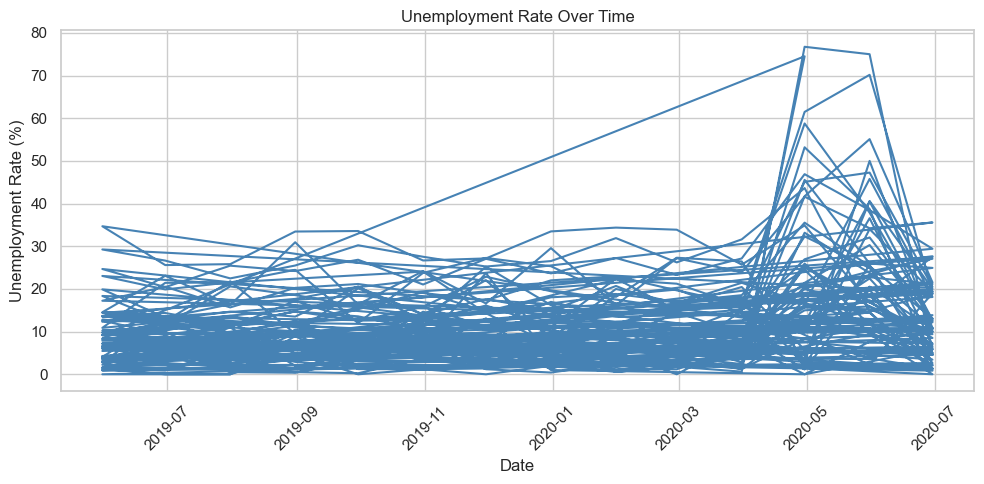

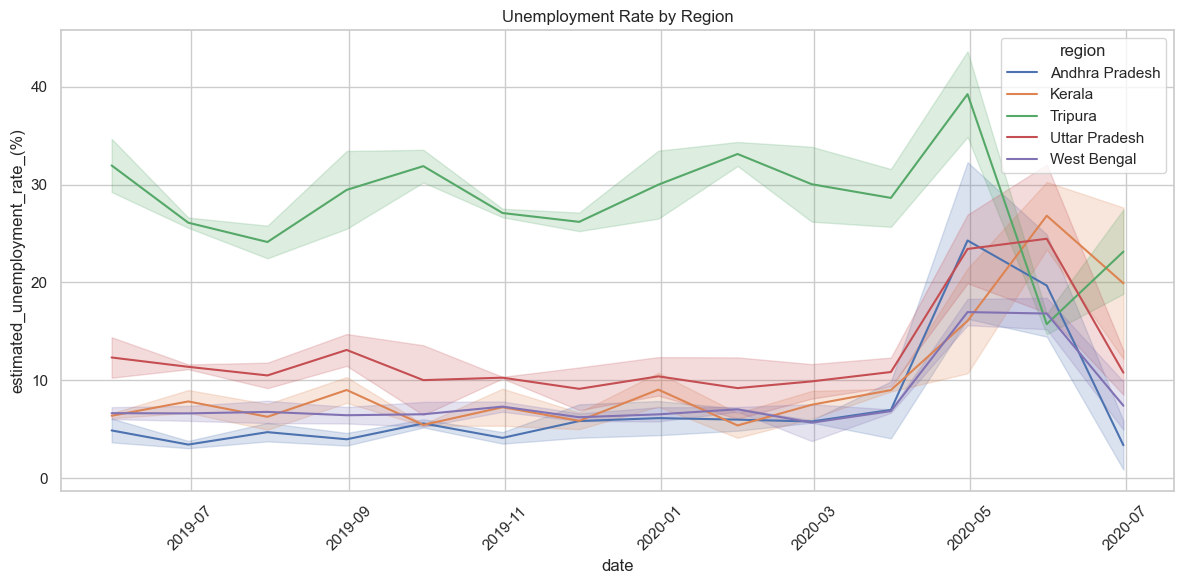

Average unemployment rate pre-COVID:  9.40%
Average unemployment rate in 2020:    15.10%
Average unemployment rate post-COVID: nan%


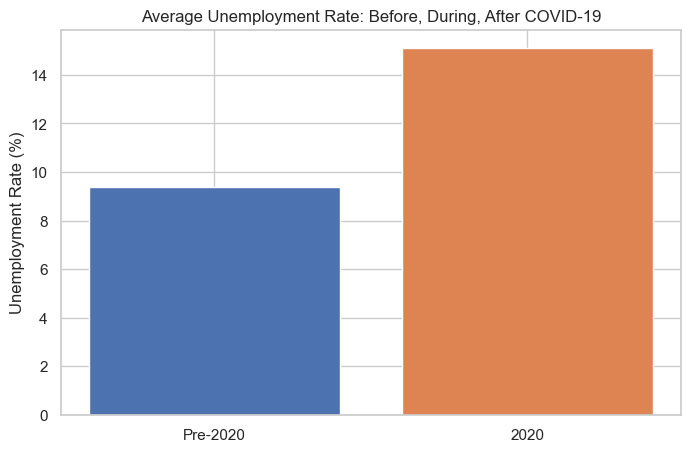

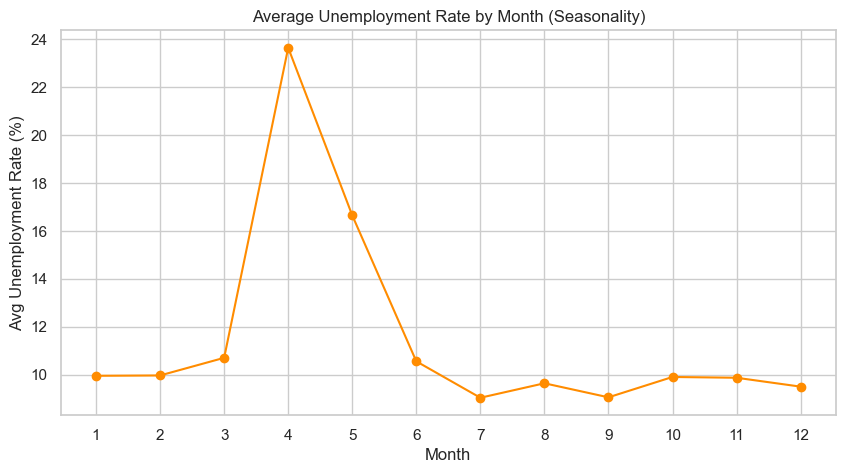

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# 1. Load Data
FILE_NAME = "Unemployment in India.csv" 
df = pd.read_csv(FILE_NAME)

# 2. Clean Data & Fix Date Warning
# This strips spaces and makes columns lowercase
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

if "date" in df.columns:
    # Added dayfirst=True to silence the warning and parse DD-MM-YYYY correctly
    df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)

df = df.dropna(how="all")
df = df.ffill() 

# Print columns to verify the exact names if it fails again
print("Dataset columns after cleaning:", df.columns.tolist())

# 3. Define Columns (Fixed to account for the '%' symbol usually in this dataset)
date_col = "date"
rate_col = "estimated_unemployment_rate_(%)" # Updated to match standard Kaggle datasets
group_col = "region" 

# 4. Overall Trend Visualization
plt.figure(figsize=(10, 5))
plt.plot(df[date_col], df[rate_col], color="steelblue")
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Trend by Region
if group_col in df.columns:
    top_groups = df[group_col].value_counts().head(5).index
    subset = df[df[group_col].isin(top_groups)]

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=subset, x=date_col, y=rate_col, hue=group_col)
    plt.title(f"Unemployment Rate by {group_col.title()}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 6. COVID-19 Impact Analysis
df["year"] = df[date_col].dt.year
pre_covid = df[df["year"] < 2020][rate_col].mean()
covid_period = df[df["year"] == 2020][rate_col].mean()
post_covid = df[df["year"] > 2020][rate_col].mean()

print(f"Average unemployment rate pre-COVID:  {pre_covid:.2f}%")
print(f"Average unemployment rate in 2020:    {covid_period:.2f}%")
print(f"Average unemployment rate post-COVID: {post_covid:.2f}%")

plt.figure(figsize=(8, 5))
plt.bar(["Pre-2020", "2020", "Post-2020"], [pre_covid, covid_period, post_covid],
        color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Average Unemployment Rate: Before, During, After COVID-19")
plt.ylabel("Unemployment Rate (%)")
plt.savefig("unemployment_covid_impact.png", dpi=200, bbox_inches="tight")
plt.show()

# 7. Seasonal Patterns
df["month"] = df[date_col].dt.month
seasonal = df.groupby("month")[rate_col].mean()

plt.figure(figsize=(10, 5))
plt.plot(seasonal.index, seasonal.values, marker="o", color="darkorange")
plt.title("Average Unemployment Rate by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Avg Unemployment Rate (%)")
plt.xticks(range(1, 13))
plt.show()